# Advanced Time Series Forecasting


## 1. Dataset 
- Data Source: Yahoo Finance
- Ticker: BTC-USD
- Frequency: Daily.
- Historical Coverage: From January 1 2020 to June 30 2026 (~6.5 years of daily observations)

### Import Libraries & Setup Environment

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import torch
from IPython.display import Image, display
import sys
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('src'))

# Import AppContainer and dependency injection components
from src.di.container import AppContainer

# Initialize the AppContainer and resolve components
container = AppContainer()
data_loader = container.data_loader()
eda_plots_usecase = container.eda_plots_usecase()
stationarity_test_usecase = container.stationarity_test_usecase()
feature_engineering_usecase = container.feature_engineering_usecase()
train_arima_usecase = container.train_arima_usecase()
train_xgb_usecase = container.train_xgb_usecase()
garch_modeling_usecase = container.garch_modeling_usecase()
evaluate_models_usecase = container.evaluate_models_usecase()

/Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2. Time Series Exploration and Preprocessing

Load and clean our daily Bitcoin price data. with usecases defined in the src.

In [2]:
# Load and clean data
raw_df = data_loader.load_data(ticker="BTC-USD", start="2020-01-01", end="2026-06-30")
raw_df.head()

2026-07-19 23:19:08,332 | INFO     | [ML_CW_Q2] Fetching daily data for BTC-USD from 2020-01-01 to 2026-06-30 via Yahoo Finance...
2026-07-19 23:19:09,035 | INFO     | [ML_CW_Q2] Successfully fetched 2372 records for BTC-USD.
2026-07-19 23:19:09,097 | INFO     | [ML_CW_Q2] Loaded 2372 rows from CollectMarketDataUseCase.
2026-07-19 23:19:09,105 | INFO     | [ML_CW_Q2] Raw data saved to /Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/Q2/data/btc_raw.csv


,timestamp_utc,open_price,high_price,low_price,close_price,volume,source
0,2020-01-01,7194.892090,7254.330566,7174.944336,7200.174316,18565664997,yahoo_finance
1,2020-01-02,7202.551270,7212.155273,6935.270020,6985.470215,20802083465,yahoo_finance
2,2020-01-03,6984.428711,7413.715332,6914.996094,7344.884277,28111481032,yahoo_finance
3,2020-01-04,7345.375488,7427.385742,7309.514160,7410.656738,18444271275,yahoo_finance
4,2020-01-05,7410.451660,7544.497070,7400.535645,7411.317383,19725074095,yahoo_finance


### Preprocessing and Anomaly Detection
- Remove unnesssary columns like Source
- Standardizing key column mappings
- Enforce Numeric and DateTime types
- Missing Values
- Negate anomalies like like negative values
- Returns Calculation: Daily returns (percentage change)


In [3]:
df_clean, close_col = data_loader.clean_data(raw_df)
df_clean.head()

2026-07-19 23:19:11,594 | INFO     | [ML_CW_Q2] Start data cleaning
2026-07-19 23:19:11,597 | INFO     | [ML_CW_Q2] No missing found
2026-07-19 23:19:11,604 | INFO     | [ML_CW_Q2] No negative found
2026-07-19 23:19:11,606 | INFO     | [ML_CW_Q2] cleaning done. missing: 0
2026-07-19 23:19:11,635 | INFO     | [ML_CW_Q2] Cleaned data saved to /Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/Q2/data/btc_cleaned.csv


,Date,Open,High,Low,Close,Volume,Returns
0,2020-01-01,7194.892090,7254.330566,7174.944336,7200.174316,18565664997,0.000000
1,2020-01-02,7202.551270,7212.155273,6935.270020,6985.470215,20802083465,-2.981929
2,2020-01-03,6984.428711,7413.715332,6914.996094,7344.884277,28111481032,5.145166
3,2020-01-04,7345.375488,7427.385742,7309.514160,7410.656738,18444271275,0.895487
4,2020-01-05,7410.451660,7544.497070,7400.535645,7411.317383,19725074095,0.008915


### Time Series Visualizations
Plots for the closing price, daily volume, and daily returns.

2026-07-19 23:19:44,122 | INFO     | [ML_CW_Q2] Generating EDA plots in plots...
2026-07-19 23:19:44,644 | INFO     | [ML_CW_Q2] Visualizations saved to directory: plots


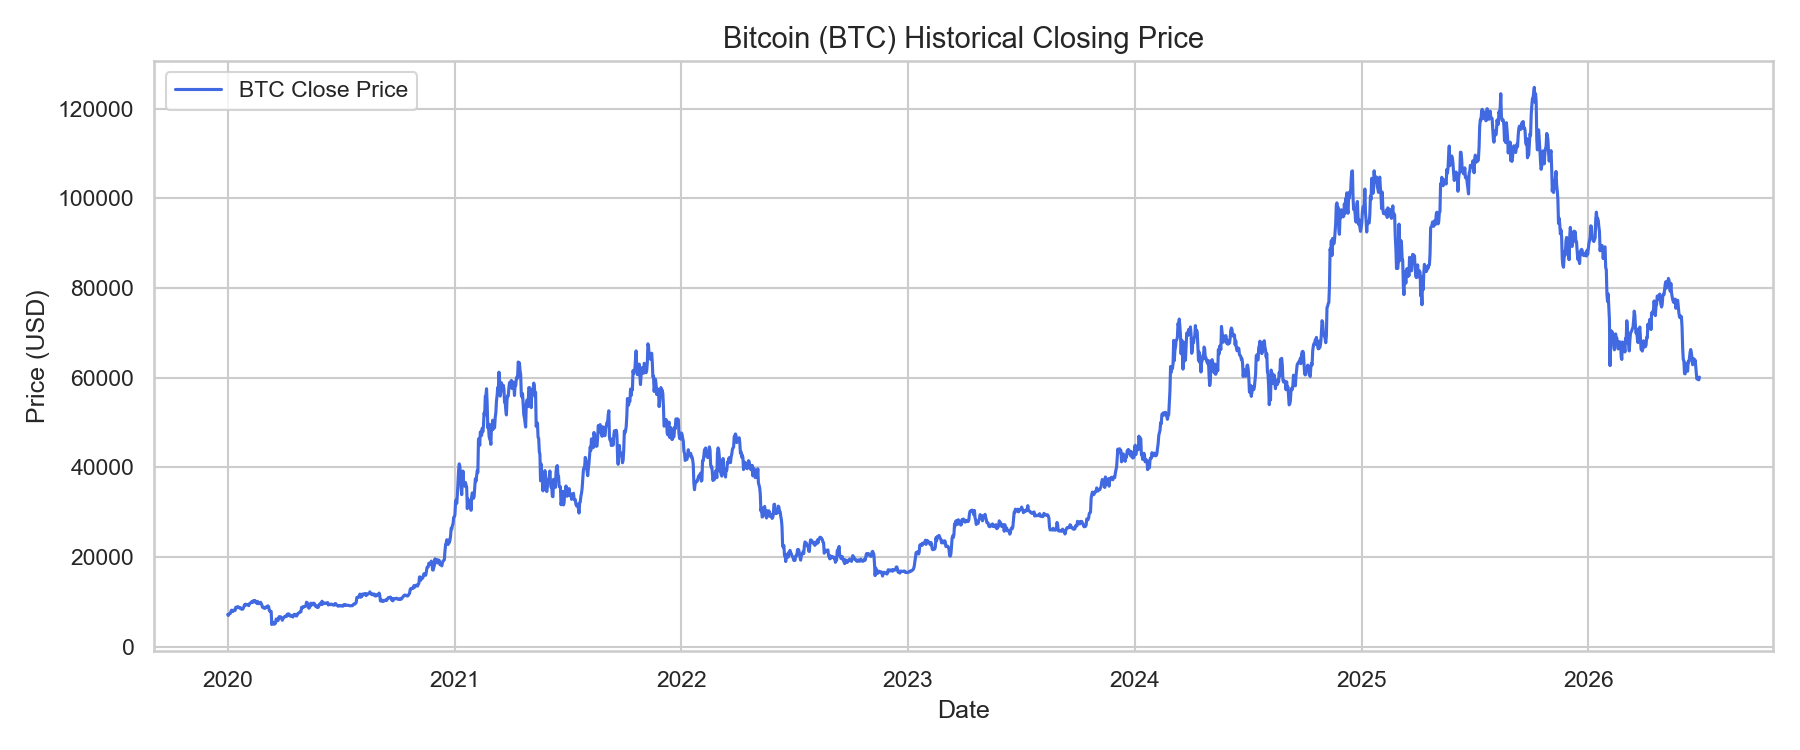

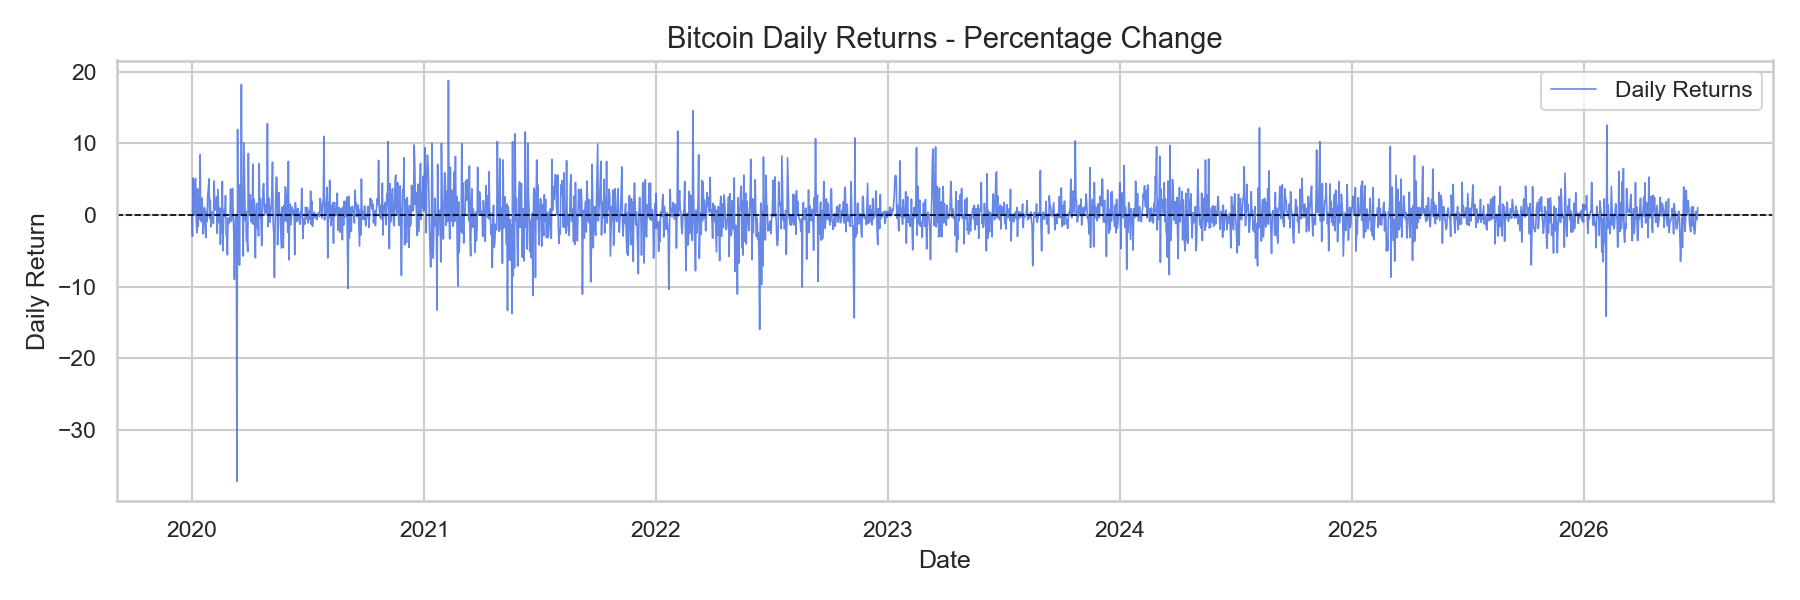

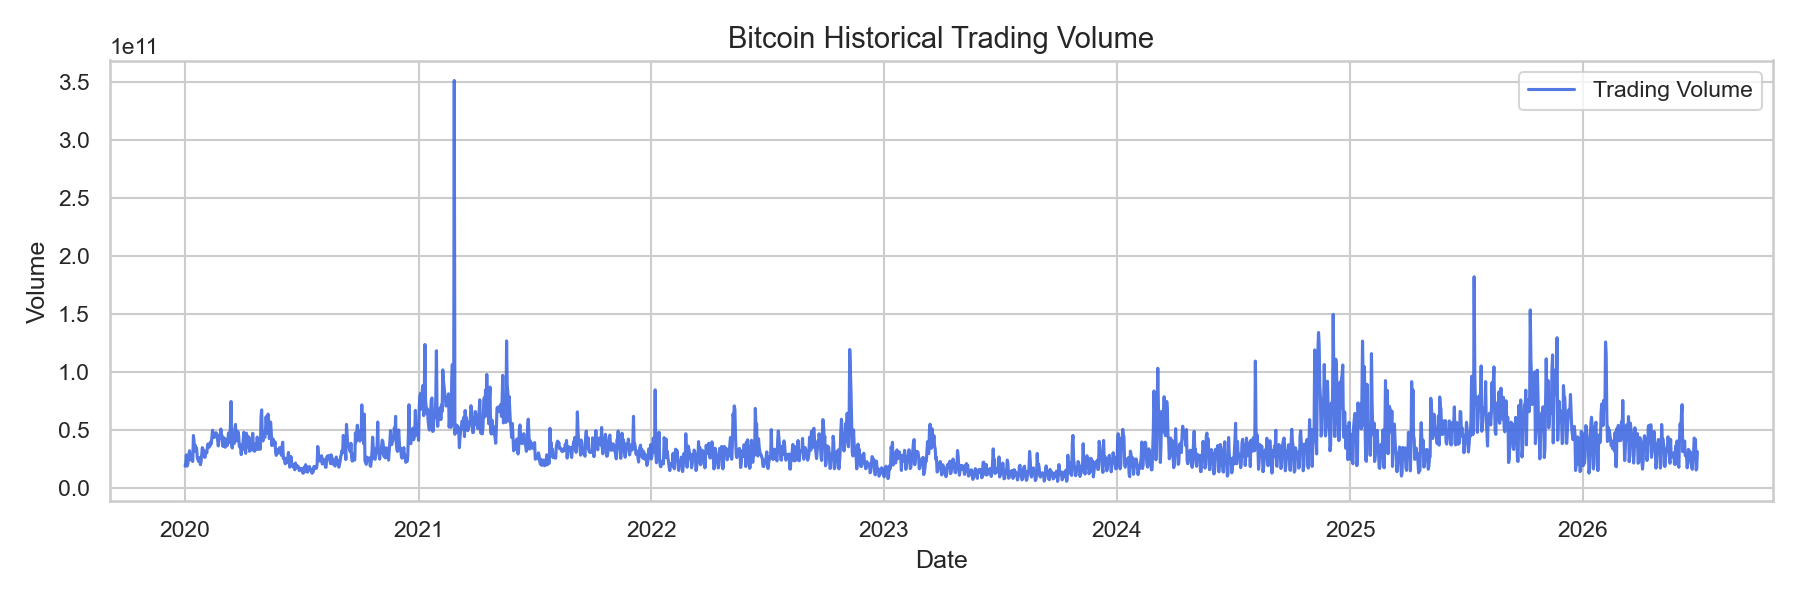

In [4]:
eda_plots_usecase.execute_plots(df_clean, close_col)

# Display generated plots
display(Image(filename='plots/btc_close_price.png'))
display(Image(filename='plots/btc_daily_returns.png'))
display(Image(filename='plots/btc_volume.png'))

### Stationarity Tests (ADF Test)
Time series modeling assumes stationarity of the series. ADF evaluates whether time series has a unit root (non stationary and trending) or its stationary.

In [5]:
print("ADF Test on Closing Price")
price_report, price_stat = stationarity_test_usecase.execute(df_clean, close_col)

print("\nADF Test on Daily Returns (Percentage Change)")
return_report, return_stat = stationarity_test_usecase.execute(df_clean, 'Returns')

ADF Test on Closing Price
2026-07-19 23:19:51,015 | INFO     | [ML_CW_Q2] Performing ADF test :'Close'...
2026-07-19 23:19:51,065 | INFO     | [ML_CW_Q2] ADF Statistic : -1.516683
2026-07-19 23:19:51,066 | INFO     | [ML_CW_Q2] p-value : 5.252429e-01
2026-07-19 23:19:51,066 | INFO     | [ML_CW_Q2] Stationarity Result : Non-Stationary (5% Significance level)

ADF Test on Daily Returns (Percentage Change)
2026-07-19 23:19:51,067 | INFO     | [ML_CW_Q2] Performing ADF test :'Returns'...
2026-07-19 23:19:51,097 | INFO     | [ML_CW_Q2] ADF Statistic : -15.871953
2026-07-19 23:19:51,097 | INFO     | [ML_CW_Q2] p-value : 8.960493e-29
2026-07-19 23:19:51,098 | INFO     | [ML_CW_Q2] Stationarity Result : Stationary (5% Significance level)


#### Interpretation ####
- Closing Price: The p-value is > 0.05, fail to reject the null hypothesis of non stationarity.
- Returns (Percentage Change): The p-value is very small (< 0.05), we reject the null hypothesis. The percentage change returns series is stationary.

### Feature Engineering
Provide local context to ML model
1. Calendar Features: Day of week, day of month, month, year, and a weekend binary indicator.
2. Lag Features: Gives model a  memory. 1 day ago. 7 days (weekly patterns), 30 days (month patterns) etc..

In [6]:
df_features = feature_engineering_usecase.execute(df_clean, close_col)
df_features.head(3)

2026-07-19 23:20:29,430 | INFO     | [ML_CW_Q2] Starting feature engineering...
2026-07-19 23:20:29,441 | INFO     | [ML_CW_Q2] Orignal shape (2372, 19), cleaned shape (2342, 19).


,Date,Open,High,Low,Close,Volume,Returns,DayOfWeek,DayOfMonth,Month,Year,IsWeekend,Lag_1,Lag_2,Lag_3,Lag_5,Lag_7,Lag_14,Lag_30
0,2020-01-31,9508.313477,9521.706055,9230.776367,9350.529297,29432489719,-1.666463,4,31,1,2020,0,9508.993164,9316.629883,9358.589844,8596.830078,8445.434570,8929.038086,7200.174316
1,2020-02-01,9346.357422,9439.323242,9313.239258,9392.875000,25922656496,0.452870,5,1,2,2020,1,9350.529297,9508.993164,9316.629883,8909.819336,8367.847656,8942.808594,6985.470215
2,2020-02-02,9389.820312,9468.797852,9217.824219,9344.365234,30835736946,-0.516453,6,2,2,2020,1,9392.875000,9350.529297,9508.993164,9358.589844,8596.830078,8706.245117,7344.884277


## 3. Model Development

Splitting
- Training Set (70%)
- Validation Set (15%) : for hyperparameter tuning
- Test Set (15%), verification from test

Chronological splitting is used over random to avoid leakages.

In [7]:
train_df, val_df, test_df = data_loader.split_data(df_features, train_ratio=0.7, val_ratio=0.15)

### ARIMA
Model params (p, d, q)

We omited seasonal orders param because bitcoin trades 24 x7 

In [8]:
best_order = train_arima_usecase.tune(train_df[close_col], p_values=[0, 1, 2], d_values=[1], q_values=[0, 1, 2])
arima_preds = train_arima_usecase.evaluate(train_df[close_col], test_df[close_col], best_order, model_path='outputs/models/arima_model.joblib')
arima_preds

2026-07-19 23:20:35,783 | INFO     | [ML_CW_Q2] Tuning ARIMA parameters


/Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/.venv/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


2026-07-19 23:20:36,154 | INFO     | [ML_CW_Q2] Best ARIMA: (2, 1, 2)
2026-07-19 23:20:36,154 | INFO     | [ML_CW_Q2] Fitting ARIMA(2, 1, 2)


/Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


0       67670.783148
1      116009.987137
2      120380.649818
3      120099.460143
4      120511.019506
           ...      
347     61121.588013
348     59748.028376
349     59871.741067
350     59810.570962
351     59502.343865
Length: 352, dtype: float64

### ML Model: XGBoost
We used engineered features and tune hyperparameters (max depth, learning rate, number of trees).

In [9]:
import xgboost as xgb
X_train, y_train = train_xgb_usecase.prepare_ml_data(train_df, close_col)
X_val, y_val = train_xgb_usecase.prepare_ml_data(val_df, close_col)
X_test, y_test = train_xgb_usecase.prepare_ml_data(test_df, close_col)

# Tune XGBoost
best_xgb_params = train_xgb_usecase.tune(X_train, y_train, X_val, y_val)

# Train final model
final_xgb = xgb.XGBRegressor(**best_xgb_params, random_state=42)
final_xgb.fit(X_train, y_train)
xgb_preds = pd.Series(final_xgb.predict(X_test), index=test_df.index)

# Save model
import joblib
import os
os.makedirs('outputs/models', exist_ok=True)
joblib.dump(final_xgb, 'outputs/models/xgboost_model.joblib')

2026-07-19 23:20:39,508 | INFO     | [ML_CW_Q2] Tuning XGBoost parameters
2026-07-19 23:20:40,574 | INFO     | [ML_CW_Q2] Best XGBoost: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03}


['outputs/models/xgboost_model.joblib']

### Model Forecasting Comparison
Calculate evaluation metrics
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

ARIMA Test Set Metrics
MAE :  USD 1580.64
RMSE : USD 3370.52
MAPE : 1.77%

XGBoost Test Set Metrics
MAE :  USD 23060.47
RMSE : USD 29707.12
MAPE : 22.23%

2026-07-19 23:20:43,398 | INFO     | [ML_CW_Q2] Plotting forecast comparison


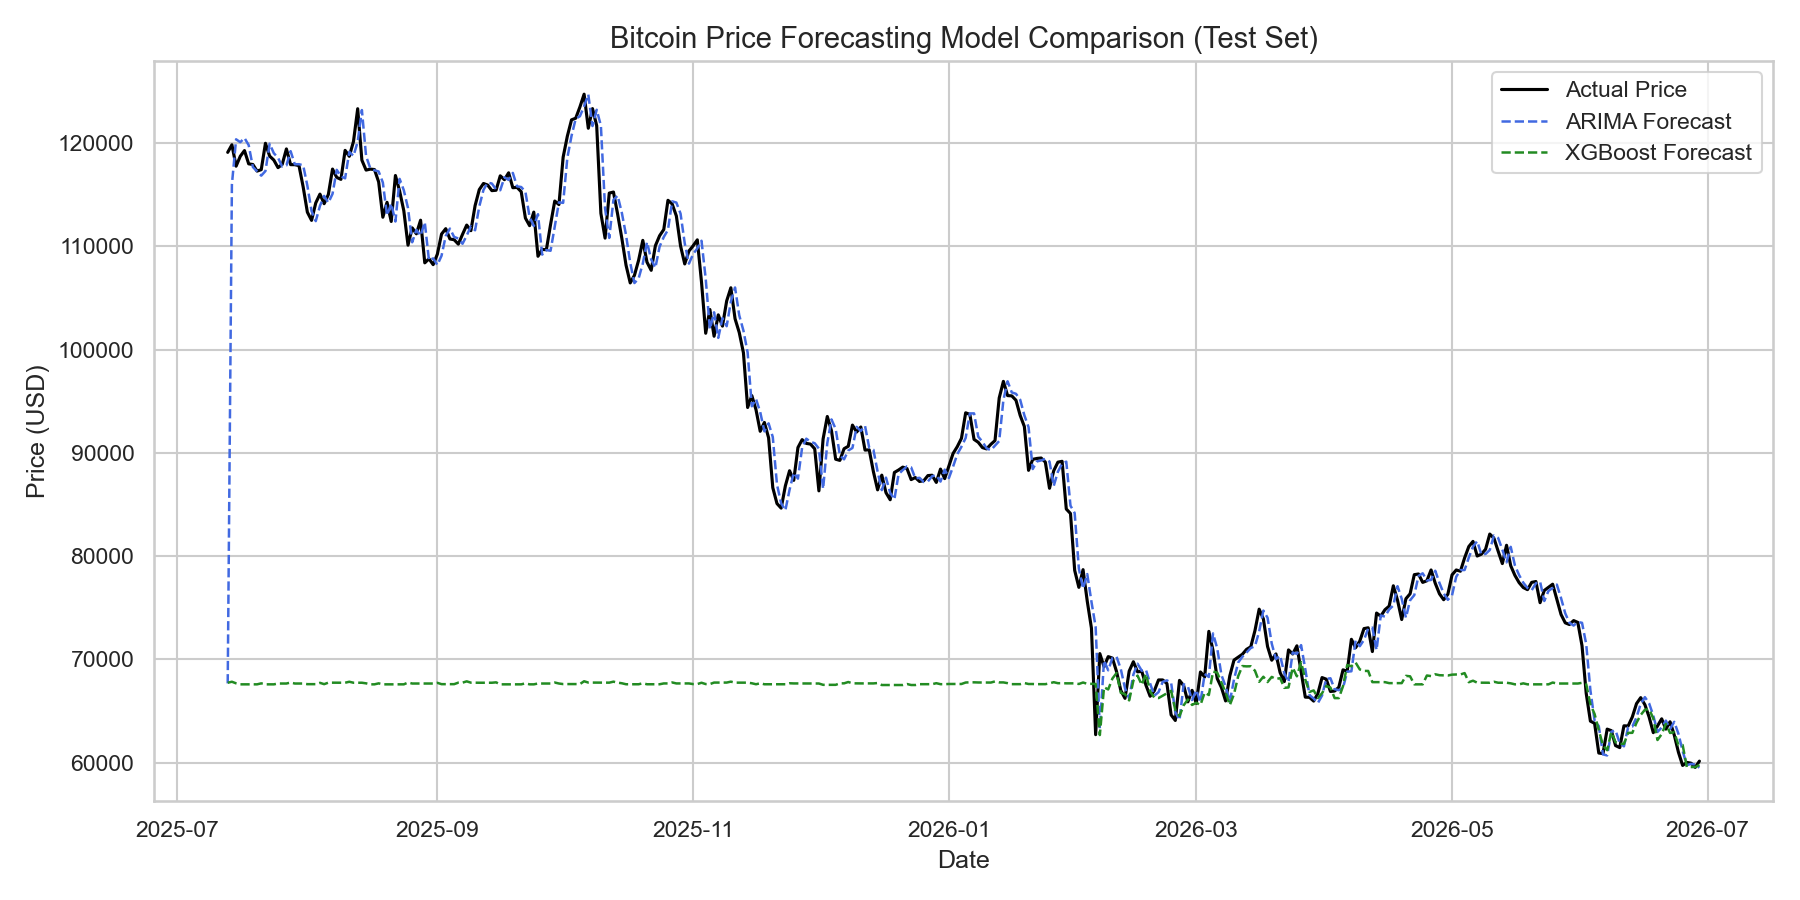

In [10]:
y_true = test_df[close_col].values
preds_dict = {'ARIMA': arima_preds, 'XGBoost': xgb_preds}

comparison_metrics = {}
for name, preds in preds_dict.items():
    metrics = evaluate_models_usecase.calculate_metrics(y_true, preds.values)
    comparison_metrics[name] = metrics
    print(f"{name} Test Set Metrics")
    print(f"MAE :  USD {metrics['MAE']:.2f}")
    print(f"RMSE : USD {metrics['RMSE']:.2f}")
    print(f"MAPE : {metrics['MAPE']:.2f}%\n")

# Forecast comparison plot
evaluate_models_usecase.plot_forecast_comparison(test_df['Date'], y_true, preds_dict)

display(Image(filename='plots/model_comparison_forecast.png'))

## 4. Volatility Modeling using GARCH

### Testing for ARCH Effects
Verify if Bitcoin daily returns show ARCH effects using ARCH-LM test


In [11]:
arch_results = garch_modeling_usecase.check_arch_effects(df_clean, returns_col='Returns')
print(arch_results)


2026-07-19 23:20:55,498 | INFO     | [ML_CW_Q2] Checking for ARCH effects on returns


2026-07-19 23:20:55,515 | INFO     | [ML_CW_Q2] ARCH-LM Test done. p-value: 1.981030e-18
{'p_value': np.float64(1.981030011091475e-18), 'has_arch_effects': np.True_}


/Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/Q2/src/task_4/domain/usecases/garch_modeling_usecase.py:23: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  _, p_val, _, _ = het_arch(returns - returns.mean(), maxlag=10)


### ARCH Test Interpretation ###
p-val is very small so we can reject null hypothesis of constant variance. This proves ARCH exisit and volatality clutering present in the BTC dataset

### Implementing the GARCH(1,1) Model
- p = Measures impact of recent market shocks on current volatality
- q = Persistance of historical volatality over time

We use p = 1, q =1, looking 1 step back for both market shock and historical volatality

Where:
- Alpha measures the immediate impact of yesterday market shock
- Beta measures the impact of historical volatality
- Persistance is the alpha + beta

In [12]:
garch_modeling_usecase.fit_garch(df_clean, returns_col='Returns', model_path='outputs/models/garch_model.joblib')

2026-07-19 23:21:21,648 | INFO     | [ML_CW_Q2] Fitting GARCH(1,1) model on scaled returns
Iteration:      1,   Func. Count:      6,   Neg. LLF: 28190.113832512987
Iteration:      2,   Func. Count:     13,   Neg. LLF: 16865.835838691328
Iteration:      3,   Func. Count:     19,   Neg. LLF: 17030.902047737392
Iteration:      4,   Func. Count:     26,   Neg. LLF: 16860.566276756235
Iteration:      5,   Func. Count:     31,   Neg. LLF: 16860.549446800513
Iteration:      6,   Func. Count:     36,   Neg. LLF: 16860.544021983536
Iteration:      7,   Func. Count:     41,   Neg. LLF: 16860.51778146337
Iteration:      8,   Func. Count:     46,   Neg. LLF: 16860.490631027427
Iteration:      9,   Func. Count:     51,   Neg. LLF: 16860.490157044707
Iteration:     10,   Func. Count:     56,   Neg. LLF: 16860.49009119635
Iteration:     11,   Func. Count:     61,   Neg. LLF: 16860.49005366579
Iteration:     12,   Func. Count:     66,   Neg. LLF: 16860.489825617988
Iteration:     13,   Func. Count:   

/Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/.venv/lib/python3.9/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 9.912e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


{'alpha': np.float64(0.0954755483299218),
 'beta': np.float64(0.8791805862211662),
 'persistence': np.float64(0.974656134551088)}

### Interpretation ###
- Alpha: 0.096 satisfies non negative condition. Model is sensitive to short term price shocks
- Beta: 0.8787 wich is significantly larger than Alpha variance much depends on long term swings rather than short term
- Volatality Persistance: This is 0.9744 which is closer to 1, this means if volatality shock enters it stays longer and decays at very slow rate.

## 5. Model Comparison, Insights, and Critical Reflection

In [13]:
metrics_df = pd.DataFrame(comparison_metrics).T
display(metrics_df)

,MAE,RMSE,MAPE
ARIMA,1580.642413,3370.519266,1.767686
XGBoost,23060.471635,29707.120507,22.231549


### Critical Reflections ###

 **Machine Learning Model (XGBoost)**:

We splits the dataset and assigned 70% for training. But starting later 2024 bitcoin reached record high which are mostly fits in the test dataset (30%). Trees cannot extrapolate predictions outside the range of target labels observed in training dataset. That is the reason for flat values capped near training maximum which is exactly what addresses in the Ernest et al
